# Algorithme de Christofides — TSP

L'algorithme de Christofides est une heuristique pour le **Problème du Voyageur de Commerce (TSP)** qui garantit une solution dont le coût ne dépasse pas **1.5× l'optimal**, à condition que le graphe respecte l'inégalité triangulaire (vrai pour les distances euclidiennes).

### Les 5 étapes

| # | Étape | Description |
|---|-------|-------------|
| 1 | **MST** | Arbre couvrant minimal sur le graphe complet |
| 2 | **Sommets impairs** | Sommets du MST ayant un degré impair |
| 3 | **Matching** | Couplage parfait de poids minimum sur ces sommets |
| 4 | **Multigraphe** | Fusion MST + matching → tous les degrés deviennent pairs |
| 5 | **Circuit** | Circuit eulérien puis court-circuitage → circuit hamiltonien |

## 0. Imports

In [1]:
import math
import json
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

## 1. Génération du graphe

On génère un **graphe complet euclidien** : `n` points aléatoires en 2D, reliés entre eux par leur distance euclidienne. L'inégalité triangulaire est automatiquement respectée, ce qui est la condition requise pour Christofides.

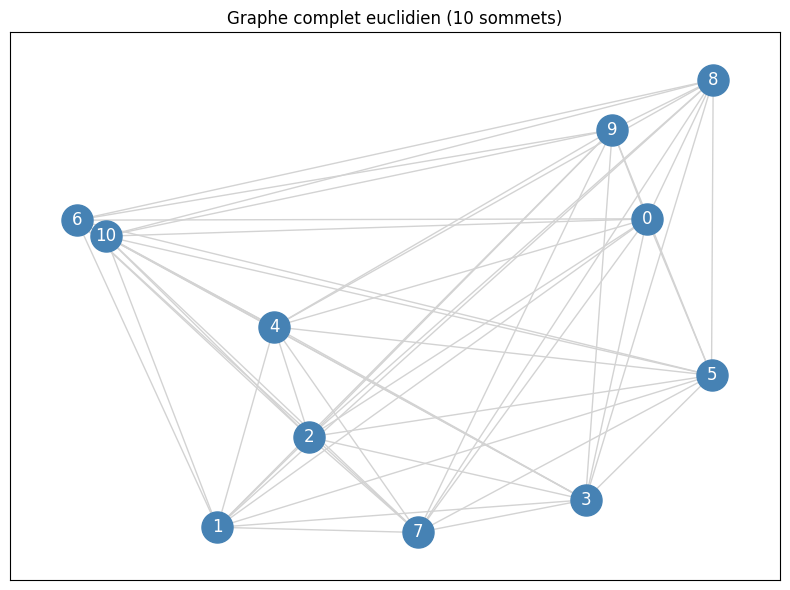

In [2]:
def generate_graph_from_json(path):
    with open(path, "r") as f:
        data = json.load(f)

    # Récupération des noeuds
    nodes = [data["depot"]] + data["clients"]

    G = nx.Graph()

    # Ajouter les noeuds avec positions
    for i, node in enumerate(nodes):
        G.add_node(i, pos=(node["x"], node["y"]))

    # Graphe complet avec distances euclidiennes
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            xi, yi = nodes[i]["x"], nodes[i]["y"]
            xj, yj = nodes[j]["x"], nodes[j]["y"]
            dist = math.hypot(xi - xj, yi - yj)
            G.add_edge(i, j, weight=dist)

    return G, data


def draw(G, edge_groups=None, title="Graphe"):
    """
    Affiche le graphe G en dessinant les arêtes en deux passes :
    d'abord les grises (fond), puis les colorées par-dessus.
    edge_groups : liste de (edges, couleur, épaisseur)
    """
    pos = nx.get_node_attributes(G, "pos")

    highlighted = {}
    if edge_groups:
        for edges, color, width in edge_groups:
            for u, v in edges:
                highlighted[(min(u,v), max(u,v))] = (color, width)

    gray_edges = [(u, v) for u, v in G.edges() if (min(u,v), max(u,v)) not in highlighted]
    
    fig, ax = plt.subplots(figsize=(8, 6))

    # Passe 1 — arêtes grises en fond
    nx.draw_networkx_edges(G, pos, edgelist=gray_edges, edge_color="lightgray", width=1, ax=ax)

    # Passe 2 — arêtes colorées par-dessus, groupe par groupe
    if edge_groups:
        for edges, color, width in edge_groups:
            nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=color, width=width, ax=ax)

    # Noeuds et labels
    nx.draw_networkx_nodes(G, pos, node_color="steelblue", node_size=500, ax=ax)
    nx.draw_networkx_labels(G, pos, font_color="white", ax=ax)

    ax.set_title(title)
    plt.tight_layout()
    plt.show()


G, data = generate_graph_from_json("datasets/tsptwd_n10.json")
draw(G, title="Graphe complet euclidien (10 sommets)")

## 2. Arbre Couvrant Minimal (MST) — Algorithme de Prim

On construit un MST avec l'algorithme de **Prim** :
- On maintient un tableau `key[v]` = coût minimum pour rattacher `v` à l'arbre
- À chaque étape, on ajoute le sommet non visité avec le `key` le plus faible
- On met à jour les `key` des voisins si on trouve une arête moins chère

Le MST retourne `n-1` arêtes qui connectent tous les sommets sans cycle.

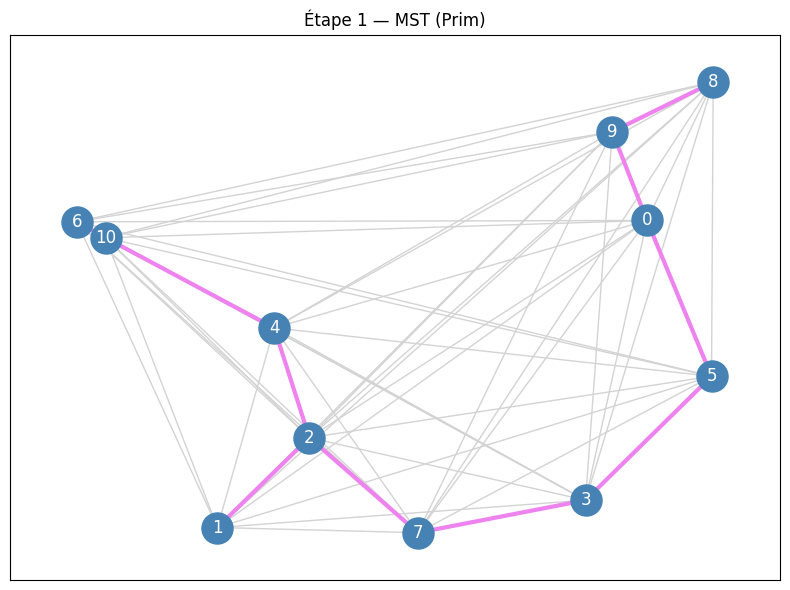

In [3]:
def prim(graph):
    n = len(graph)
    key = [math.inf] * n
    key[0] = 0
    parent = [None] * n
    visited = set()

    while len(visited) != n:
        # Sommet non visité avec le coût d'accès minimum
        not_visited = [v for v in range(n) if v not in visited]
        u = min(not_visited, key=lambda v: key[v])
        visited.add(u)

        # Mise à jour des voisins
        for v in graph[u]:
            if v not in visited:
                w = graph[u][v]['weight']
                if w < key[v]:
                    key[v] = w
                    parent[v] = u

    return [(parent[v], v) for v in range(n) if parent[v] is not None]


mst_edges = prim(G)
draw(G, edge_groups=[(mst_edges, "violet", 3)], title="Étape 1 — MST (Prim)")

## 3. Sommets de degré impair

Par le théorème des poignées de mains, il y a toujours un nombre **pair** de sommets de degré impair dans un graphe. On les identifie pour l'étape suivante.

In [4]:
def odd_degree_nodes(mst_edges):
    cnt = Counter(v for edge in mst_edges for v in edge)
    return sorted(v for v in cnt if cnt[v] % 2 != 0)


odd_nodes = odd_degree_nodes(mst_edges)
print(f"Sommets de degré impair : {odd_nodes}")

Sommets de degré impair : [1, 2, 6, 8]


## 4. Couplage parfait de poids minimum

On extrait le **sous-graphe induit** par les sommets impairs, puis on trouve le couplage parfait de poids minimum via l'algorithme de Blossom d'Edmonds (fourni par NetworkX).

Chaque sommet impair sera apparié exactement une fois, ce qui augmentera son degré de 1 → le rendra pair.

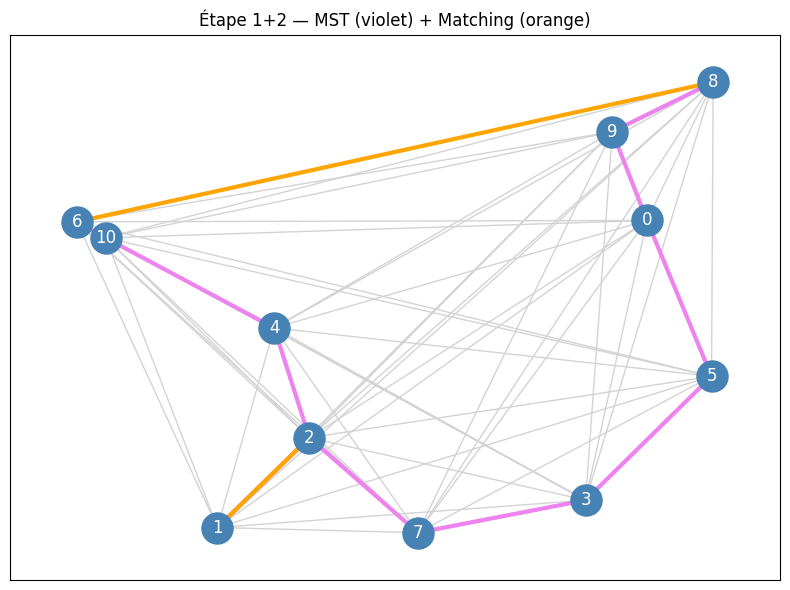

In [5]:
def min_matching(G, odd_nodes):
    subgraph = G.subgraph(odd_nodes)
    return list(nx.min_weight_matching(subgraph))


matching_edges = min_matching(G, odd_nodes)
draw(G,
     edge_groups=[(mst_edges, "violet", 3), (matching_edges, "orange", 3)],
     title="Étape 1+2 — MST (violet) + Matching (orange)")

## 5. Multigraphe eulérien

On fusionne les arêtes du MST et du matching dans un `MultiGraph` (qui accepte plusieurs arêtes entre deux mêmes sommets). Après la fusion, **tous les sommets ont un degré pair** — condition nécessaire et suffisante pour l'existence d'un circuit eulérien (théorème d'Euler).

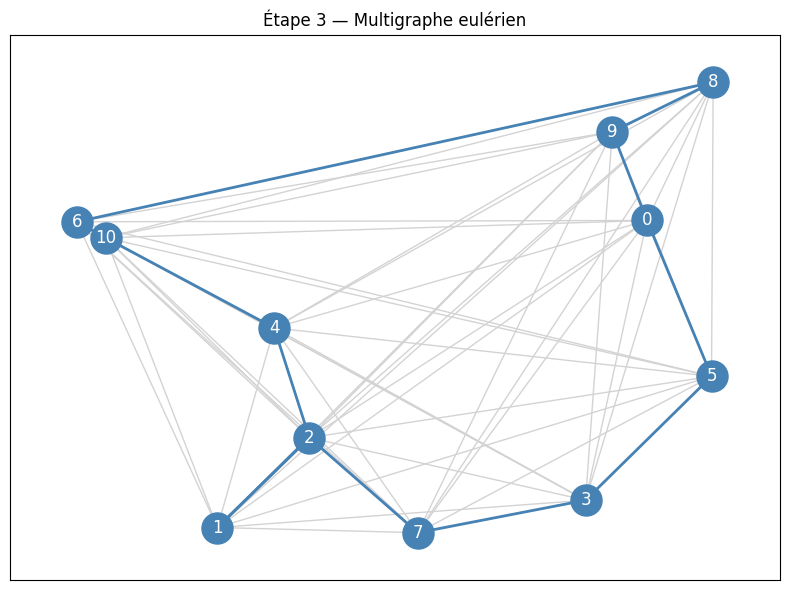

In [6]:
def build_multigraph(G, mst_edges, matching_edges):
    MG = nx.MultiGraph()
    MG.add_nodes_from(G.nodes(data=True))
    MG.add_edges_from((u, v, {'weight': G[u][v]['weight']}) for u, v in mst_edges)
    MG.add_edges_from((u, v, {'weight': G[u][v]['weight']}) for u, v in matching_edges)
    return MG


multigraph = build_multigraph(G, mst_edges, matching_edges)
all_mg_edges = list(multigraph.edges())
draw(G,
     edge_groups=[(all_mg_edges, "steelblue", 2)],
     title="Étape 3 — Multigraphe eulérien")

## 6. Circuit eulérien → Circuit hamiltonien

1. On extrait un **circuit eulérien** (passe par chaque arête exactement une fois) via l'algorithme de Hierholzer.
2. On **court-circuite** les sommets déjà visités pour obtenir un circuit hamiltonien (chaque sommet exactement une fois). Cela est valide grâce à l'inégalité triangulaire : sauter une ville ne peut qu'améliorer ou maintenir le coût.

In [7]:
def eulerian_to_hamiltonian(multigraph):
    visited = set()
    hamiltonian = []
    for u, v in nx.eulerian_circuit(multigraph):
        if u not in visited:
            hamiltonian.append(u)
            visited.add(u)
    hamiltonian.append(hamiltonian[0])  # Fermer le circuit
    return hamiltonian


hamiltonian = eulerian_to_hamiltonian(multigraph)

circuit = list(nx.eulerian_circuit(multigraph))
euler = [u for u, v in circuit] + [circuit[-1][1]]
print("Circuit eulérien  :", " → ".join(str(v) for v in euler))
print("Circuit hamiltonien:", " → ".join(str(v) for v in hamiltonian))

Circuit eulérien  : 0 → 9 → 8 → 6 → 10 → 4 → 2 → 1 → 2 → 7 → 3 → 5 → 0
Circuit hamiltonien: 0 → 9 → 8 → 6 → 10 → 4 → 2 → 1 → 7 → 3 → 5 → 0


## 7. Algorithme complet

On regroupe toutes les étapes dans une seule fonction `christofides(G)`.

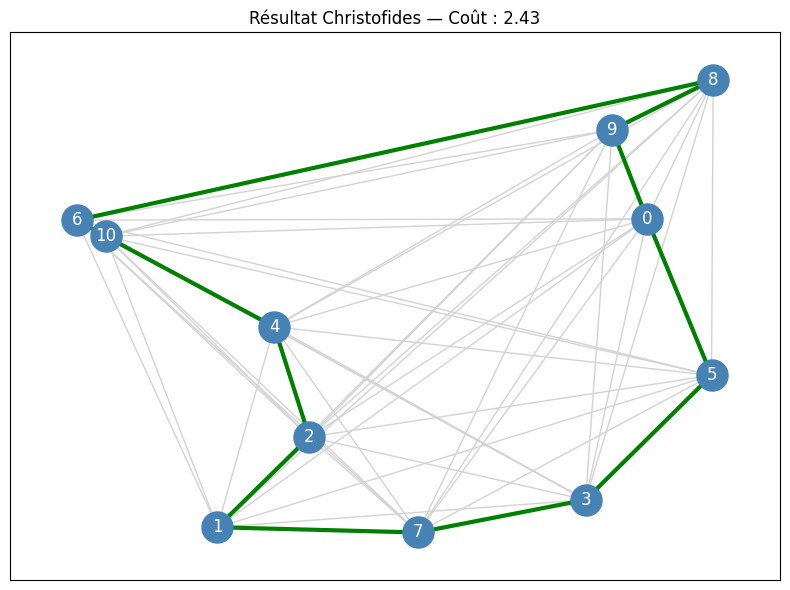

Circuit : [0, 9, 8, 6, 10, 4, 2, 1, 7, 3, 5, 0]
Coût total : 2.43


In [8]:
def christofides(G):
    mst_edges      = prim(G)
    odd_nodes      = odd_degree_nodes(mst_edges)
    matching_edges = min_matching(G, odd_nodes)
    multigraph     = build_multigraph(G, mst_edges, matching_edges)
    hamiltonian    = eulerian_to_hamiltonian(multigraph)
    return hamiltonian


def tour_cost(G, hamiltonian):
    return sum(G[hamiltonian[i]][hamiltonian[i+1]]['weight'] for i in range(len(hamiltonian) - 1))


# Résultat
G, _ = generate_graph_from_json("datasets/tsptwd_n10.json")
hamiltonian = christofides(G)
cost = tour_cost(G, hamiltonian)

ham_edges = list(zip(hamiltonian[:-1], hamiltonian[1:]))
draw(G,
     edge_groups=[(ham_edges, "green", 3)],
     title=f"Résultat Christofides — Coût : {cost:.2f}")
print(f"Circuit : {hamiltonian}")
print(f"Coût total : {cost:.2f}")

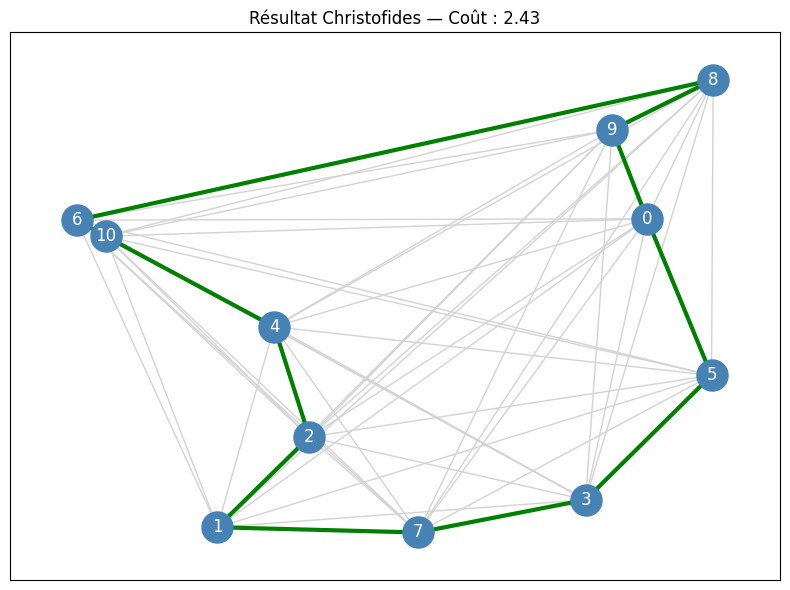

Circuit : [0, 9, 8, 6, 10, 4, 2, 1, 7, 3, 5, 0]
Coût total : 2.43


In [10]:
def all_in_one(size):
    G, _ = generate_graph_from_json("datasets/tsptwd_n10.json")
    hamiltonian = christofides(G)
    cost = tour_cost(G, hamiltonian)

    ham_edges = list(zip(hamiltonian[:-1], hamiltonian[1:]))
    draw(G,
        edge_groups=[(ham_edges, "green", 3)],
        title=f"Résultat Christofides — Coût : {cost:.2f}")
    print(f"Circuit : {hamiltonian}")
    print(f"Coût total : {cost:.2f}")

all_in_one(50)